# NLP Hands-On Demo: End-to-End Text Processing & Modelling

**Dataset:** Gojek App Reviews (10,000 samples)  
**Language:** Indonesian (Bahasa Indonesia)

In [82]:
# Install required libraries
!pip install nltk gensim emoji tensorflow -q
print('Installation complete.')

Installation complete.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [83]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
import emoji as emoji_lib
from nltk.tokenize import word_tokenize
from nltk.tag import pos_tag
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.decomposition import PCA

from gensim.models import Word2Vec, FastText
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import seaborn as sns

for resource in ['punkt', 'punkt_tab', 'averaged_perceptron_tagger',
                 'averaged_perceptron_tagger_eng', 'stopwords']:
    nltk.download(resource, quiet=True)

print('All libraries loaded.')

All libraries loaded.


---
## 0. Load Dataset

In [84]:
df_full = pd.read_csv('clean_reviews.csv')
print(f'Full dataset : {df_full.shape}')

# Sample 10,000 rows
df = df_full.sample(n=10000, random_state=42).reset_index(drop=True)
print(f'Sampled      : {df.shape}')
print(f'Columns      : {df.columns.tolist()}')
print(f'\nLabel distribution:')
print(df['label'].value_counts())
df[['text_original','text','label','text_sentiment']].head(5)

Full dataset : (125590, 14)
Sampled      : (10000, 14)
Columns      : ['app', 'app_id', 'username', 'rating', 'text', 'text_original', 'thumbs_up', 'date', 'reply', 'lang', 'word_count', 'text_sentiment', 'sentiment_confidence', 'label']

Label distribution:
label
0    8951
1    1049
Name: count, dtype: int64


,text_original,text,label,text_sentiment
0,kenapa akun saya harus 500 folower . gimana de...,kenapa akun saya harus 500 folower . gimana de...,0,NEGATIVE
1,bagus apl ini aku suka blanja disini semua bar...,bagus apl ini aku suka blanja disini semua bar...,0,POSITIVE
2,Jdi males belanja di toko pedia ga ada gratis ...,jdi males belanja di toko pedia ga ada gratis ...,0,NEGATIVE
3,alhmdulillah semoga sllu aman dlm berkendaraan,alhmdulillah semoga sllu aman dlm berkendaraan,0,POSITIVE
4,pake apk ini dah cukup lama sampai saldo pay l...,pake apk ini dah cukup lama sampai saldo pay l...,0,POSITIVE


---
## Section 1: Text Preprocessing

Raw text contains noise that hurts model performance. We apply five steps:  
Cleaning → Casefolding → Tokenisasi → POS Tagging → Stopword Removal

### 1.1 Text Cleaning

Remove noise:
- **Emoji** (e.g. smiley, thumbs-up, fire characters)
- **URLs** (http://, www.)
- **HTML tags** (`<br>`, `<b>`, …)
- **Special characters** (!@#$%)
- **Extra whitespace**

We use `text_original` (uncleaned) to demonstrate.

In [85]:
def clean_text(text):
    if not isinstance(text, str):
        return ''
    # Remove emoji
    text = emoji_lib.replace_emoji(text, replace='')
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)
    # Keep only letters, digits, spaces
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    # Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# --- Demo ---
sample_texts = [
    'Aplikasi bagus banget!! Harga naik mulu tapi kualitas turun. Visit https://gojek.com',
    'Driver <b>sangat ramah</b> & profesional @#$%! Recommended!!!',
    df['text_original'].iloc[0],
    df['text_original'].iloc[1],
]

print('=== Text Cleaning Demo ===\n')
for i, t in enumerate(sample_texts):
    c = clean_text(t)
    print(f'[{i+1}] Before : {t[:90]}')
    print(f'    After  : {c[:90]}')
    print()

=== Text Cleaning Demo ===

[1] Before : Aplikasi bagus banget!! Harga naik mulu tapi kualitas turun. Visit https://gojek.com
    After  : Aplikasi bagus banget Harga naik mulu tapi kualitas turun Visit

[2] Before : Driver <b>sangat ramah</b> & profesional @#$%! Recommended!!!
    After  : Driver sangat ramah profesional Recommended

[3] Before : kenapa akun saya harus 500 folower . gimana dengan pesanan saya
    After  : kenapa akun saya harus 500 folower gimana dengan pesanan saya

[4] Before : bagus apl ini aku suka blanja disini semua barang ORI sesuai pesenan
    After  : bagus apl ini aku suka blanja disini semua barang ORI sesuai pesenan



### 1.2 Casefolding

Convert all text to **lowercase** so `Bagus`, `bagus`, `BAGUS` are treated as one token.

In [86]:
def casefolding(text):
    return text.lower()

examples = [
    'Driver SANGAT Ramah dan Profesional',
    'APLIKASI Bagus Tapi SERING ERROR',
    'Pelayanan Oke Top Markotop',
]

print('=== Casefolding Demo ===\n')
for t in examples:
    print(f'  Before : {t}')
    print(f'  After  : {casefolding(t)}')
    print()

=== Casefolding Demo ===

  Before : Driver SANGAT Ramah dan Profesional
  After  : driver sangat ramah dan profesional

  Before : APLIKASI Bagus Tapi SERING ERROR
  After  : aplikasi bagus tapi sering error

  Before : Pelayanan Oke Top Markotop
  After  : pelayanan oke top markotop



### 1.3 Tokenisasi

Split a sentence into individual **tokens** (words/punctuation) using NLTK `word_tokenize`.

In [87]:
def tokenize(text):
    return word_tokenize(text)

examples = [
    'aplikasi bagus tapi sering error',
    'driver sangat ramah dan tepat waktu',
    'tidak bisa login sudah coba berkali kali',
]

print('=== Tokenisasi Demo ===\n')
for t in examples:
    tokens = tokenize(t)
    print(f'  Input  : {t}')
    print(f'  Tokens : {tokens}')
    print(f'  Count  : {len(tokens)} token(s)')
    print()

=== Tokenisasi Demo ===

  Input  : aplikasi bagus tapi sering error
  Tokens : ['aplikasi', 'bagus', 'tapi', 'sering', 'error']
  Count  : 5 token(s)

  Input  : driver sangat ramah dan tepat waktu
  Tokens : ['driver', 'sangat', 'ramah', 'dan', 'tepat', 'waktu']
  Count  : 6 token(s)

  Input  : tidak bisa login sudah coba berkali kali
  Tokens : ['tidak', 'bisa', 'login', 'sudah', 'coba', 'berkali', 'kali']
  Count  : 7 token(s)



### 1.4 POS Tagging (Part-of-Speech Tagging)

Label each token with its grammatical role:

| Tag | Meaning | Tag | Meaning |
|-----|---------|-----|--------|
| NN  | Noun    | VB  | Verb   |
| JJ  | Adjective | RB | Adverb |
| DT  | Determiner | IN | Preposition |

> **Note:** NLTK's tagger is trained on English. For Indonesian text the tags are approximate, but demonstrate the concept.

In [88]:
examples_eng = [
    'good application but sometimes slow',
    'driver very kind and always on time',
    'cannot login tried many times already',
]

print('=== POS Tagging Demo ===\n')
for t in examples_eng:
    tokens = tokenize(t)
    tagged = pos_tag(tokens)
    print(f'  Input  : {t}')
    for word, tag in tagged:
        print(f'    {word:15s} -> {tag}')
    print()

=== POS Tagging Demo ===

  Input  : good application but sometimes slow
    good            -> JJ
    application     -> NN
    but             -> CC
    sometimes       -> RB
    slow            -> VB

  Input  : driver very kind and always on time
    driver          -> RB
    very            -> RB
    kind            -> NN
    and             -> CC
    always          -> RB
    on              -> IN
    time            -> NN

  Input  : cannot login tried many times already
    can             -> MD
    not             -> RB
    login           -> VB
    tried           -> VBD
    many            -> JJ
    times           -> NNS
    already         -> RB



### 1.5 Stopword Removal

Remove high-frequency words that carry little discriminative meaning  
(e.g. *dan, yang, di, ke, the, is, a*).

In [89]:
indonesian_stops = set(stopwords.words('indonesian'))
english_stops    = set(stopwords.words('english'))
custom_stops = {
    'yg','jg','ga','gak','nggak','udah','aja','tapi','kalo','kalau',
    'banget','kayak','lagi','mau','juga','bisa','ada','sudah','saya',
    'kamu','kami','mereka','ya','nya','ku','mu'
}
all_stops = indonesian_stops | english_stops | custom_stops

def remove_stopwords(tokens):
    return [t for t in tokens if t.lower() not in all_stops and len(t) > 1]

examples = [
    ['aplikasi','ini','sangat','bagus','dan','membantu','sekali'],
    ['saya','tidak','bisa','login','sudah','coba','berkali','kali'],
    ['driver','yang','sangat','ramah','dan','tepat','waktu'],
]

print(f'Total stopwords loaded: {len(all_stops)}\n')
print('=== Stopword Removal Demo ===\n')
for tokens in examples:
    filtered = remove_stopwords(tokens)
    removed  = [t for t in tokens if t not in filtered]
    print(f'  Before  : {tokens}')
    print(f'  After   : {filtered}')
    print(f'  Removed : {removed}')
    print()

Total stopwords loaded: 969

=== Stopword Removal Demo ===

  Before  : ['aplikasi', 'ini', 'sangat', 'bagus', 'dan', 'membantu', 'sekali']
  After   : ['aplikasi', 'bagus', 'membantu']
  Removed : ['ini', 'sangat', 'dan', 'sekali']

  Before  : ['saya', 'tidak', 'bisa', 'login', 'sudah', 'coba', 'berkali', 'kali']
  After   : ['login', 'coba', 'berkali', 'kali']
  Removed : ['saya', 'tidak', 'bisa', 'sudah']

  Before  : ['driver', 'yang', 'sangat', 'ramah', 'dan', 'tepat', 'waktu']
  After   : ['driver', 'ramah']
  Removed : ['yang', 'sangat', 'dan', 'tepat', 'waktu']



### Full Preprocessing Pipeline

Apply all steps to the entire dataset.

In [90]:
def preprocess(text):
    text   = clean_text(text)
    text   = casefolding(text)
    tokens = tokenize(text)
    tokens = remove_stopwords(tokens)
    return tokens

print('Applying pipeline to 10,000 reviews...')
df['tokens']     = df['text_original'].apply(preprocess)
df['text_clean'] = df['tokens'].apply(lambda x: ' '.join(x))
print('Done!\n')

print('Sample results:')
for i in range(3):
    print(f'\n[{i+1}] Original : {df["text_original"].iloc[i][:80]}')
    print(f'    Tokens   : {df["tokens"].iloc[i][:8]}...')
    print(f'    Clean    : {df["text_clean"].iloc[i][:80]}')

Applying pipeline to 10,000 reviews...
Done!

Sample results:

[1] Original : kenapa akun saya harus 500 folower . gimana dengan pesanan saya
    Tokens   : ['akun', '500', 'folower', 'gimana', 'pesanan']...
    Clean    : akun 500 folower gimana pesanan

[2] Original : bagus apl ini aku suka blanja disini semua barang ORI sesuai pesenan
    Tokens   : ['bagus', 'apl', 'suka', 'blanja', 'barang', 'ori', 'sesuai', 'pesenan']...
    Clean    : bagus apl suka blanja barang ori sesuai pesenan

[3] Original : Jdi males belanja di toko pedia ga ada gratis ongkir dan diskon nya cuma sekali 
    Tokens   : ['jdi', 'males', 'belanja', 'toko', 'pedia', 'gratis', 'ongkir', 'diskon']...
    Clean    : jdi males belanja toko pedia gratis ongkir diskon ja gratis ongkir diskon lbh se


---
## Section 2: Feature Extraction

Convert text into numerical vectors that ML models can consume.  
**Bag of Words → TF-IDF → N-gram**

### 2.1 Bag of Words (BoW)

Represent each document as a **count vector** over the vocabulary.  
Word order is ignored. Sparse, high-dimensional.

=== Bag of Words ===
Vocabulary size : 5000
Matrix shape    : (10000, 5000)
Matrix density  : 0.00181 (mostly zeros = sparse)

Top 20 most frequent words:
  Word                 Count
  ----------------------------
  aplikasi              2019
  dana                  1490
  tolong                 999
  barang                 956
  shopee                 952
  driver                 877
  bca                    847
  bagus                  795
  belanja                727
  masuk                  649
  update                 647
  transaksi              627
  saldo                  624
  tokopedia              597
  apk                    580
  gk                     563
  gojek                  555
  pake                   525
  membantu               507
  susah                  506


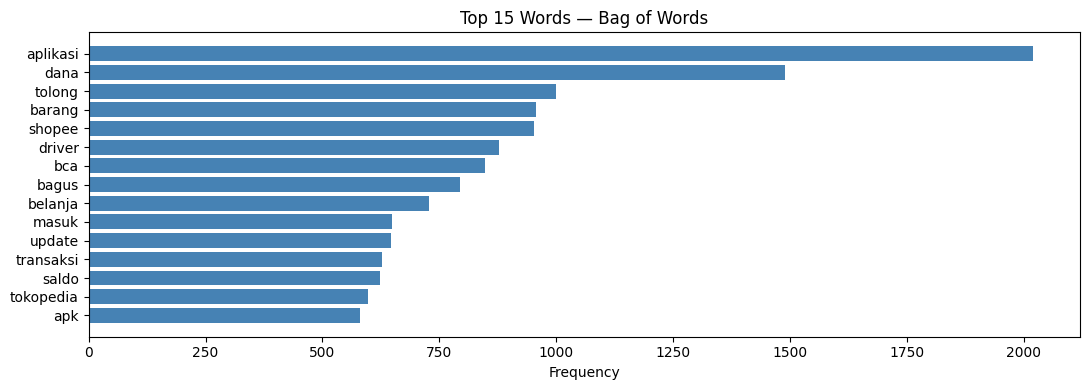


Doc-0 non-zero entries:
  "500": 1
  "akun": 1
  "gimana": 1
  "pesanan": 1


In [91]:
bow_vec = CountVectorizer(max_features=5000, min_df=2)
X_bow   = bow_vec.fit_transform(df['text_clean'])
vocab_bow = bow_vec.get_feature_names_out()

print('=== Bag of Words ===')
print(f'Vocabulary size : {len(vocab_bow)}')
print(f'Matrix shape    : {X_bow.shape}')
density = X_bow.nnz / (X_bow.shape[0] * X_bow.shape[1])
print(f'Matrix density  : {density:.5f} (mostly zeros = sparse)')

# Top 20 most frequent words
word_freq = np.asarray(X_bow.sum(axis=0)).flatten()
top_idx   = word_freq.argsort()[::-1][:20]

print('\nTop 20 most frequent words:')
print(f'  {"Word":<20} Count')
print('  ' + '-'*28)
for i, idx in enumerate(top_idx):
    print(f'  {vocab_bow[idx]:<20} {int(word_freq[idx]):>5}')

# Plot
fig, ax = plt.subplots(figsize=(11, 4))
top15 = top_idx[:15]
ax.barh([vocab_bow[i] for i in top15][::-1],
        [word_freq[i] for i in top15][::-1], color='steelblue')
ax.set_xlabel('Frequency')
ax.set_title('Top 15 Words — Bag of Words')
plt.tight_layout(); plt.show()

# Show one document vector
print('\nDoc-0 non-zero entries:')
doc0 = X_bow[0].toarray().flatten()
for idx in np.where(doc0 > 0)[0][:10]:
    print(f'  "{vocab_bow[idx]}": {int(doc0[idx])}')

### 2.2 TF-IDF (Term Frequency – Inverse Document Frequency)

**TF-IDF = TF × IDF**  
- **TF**: how often a word appears in *this* document  
- **IDF**: penalises words that appear in *many* documents (common → less informative)  

Result: words unique to a document get high weight; ubiquitous words get low weight.

=== TF-IDF ===
Vocabulary size : 5000
Matrix shape    : (10000, 5000)

High IDF (rare / informative words):
  yallah                    IDF=9.112
  konfirm                   IDF=9.112
  konfir                    IDF=9.112
  komsumen                  IDF=9.112
  komputer                  IDF=9.112
  komplin                   IDF=9.112
  komplenan                 IDF=9.112
  komplainnya               IDF=9.112
  komitmen                  IDF=9.112
  kokoh                     IDF=9.112
  kodenya                   IDF=9.112
  1km                       IDF=9.112
  17k                       IDF=9.112
  win                       IDF=9.112
  xiaomi                    IDF=9.112

Low IDF (common / less informative):
  aplikasi                  IDF=2.779
  dana                      IDF=3.245
  tolong                    IDF=3.385
  bagus                     IDF=3.582
  barang                    IDF=3.615
  shopee                    IDF=3.644
  bca                       IDF=3.715
  belanja         

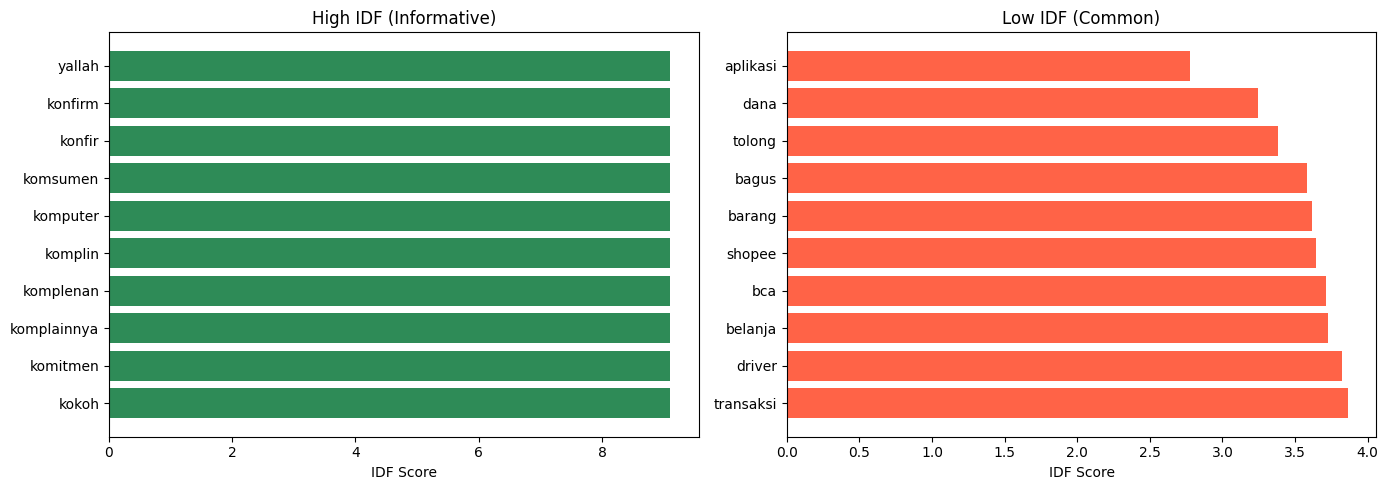

In [92]:
tfidf_vec = TfidfVectorizer(max_features=5000, min_df=2)
X_tfidf   = tfidf_vec.fit_transform(df['text_clean'])
vocab_tfidf = tfidf_vec.get_feature_names_out()
idf_scores  = tfidf_vec.idf_

print('=== TF-IDF ===')
print(f'Vocabulary size : {len(vocab_tfidf)}')
print(f'Matrix shape    : {X_tfidf.shape}')

high_idf = idf_scores.argsort()[::-1][:15]
low_idf  = idf_scores.argsort()[:15]

print('\nHigh IDF (rare / informative words):')
for idx in high_idf:
    print(f'  {vocab_tfidf[idx]:<25} IDF={idf_scores[idx]:.3f}')

print('\nLow IDF (common / less informative):')
for idx in low_idf:
    print(f'  {vocab_tfidf[idx]:<25} IDF={idf_scores[idx]:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, indices, title, color in [
    (axes[0], high_idf[:10], 'High IDF (Informative)', 'seagreen'),
    (axes[1], low_idf[:10],  'Low IDF (Common)',       'tomato'),
]:
    ax.barh([vocab_tfidf[i] for i in indices][::-1],
            [idf_scores[i]  for i in indices][::-1], color=color)
    ax.set_title(title); ax.set_xlabel('IDF Score')
plt.tight_layout(); plt.show()

### 2.3 N-gram

Extend BoW to capture **phrases**:
- Bigram (2-gram): `['bagus banget', 'tepat waktu']`
- Trigram (3-gram): `['sangat tepat waktu']`

Useful for catching multi-word expressions that carry meaning together.

Top 15 Bigrams:
   1. "dana cicil"  (340)
   2. "bca mobile"  (184)
   3. "gratis ongkir"  (160)
   4. "terima kasih"  (140)
   5. "tolong perbaiki"  (132)
   6. "force close"  (128)
   7. "fitur dana"  (106)
   8. "aplikasi dana"  (102)
   9. "belanja online"  (95)
  10. "aplikasi bagus"  (92)
  11. "belanja shopee"  (85)
  12. "kasih bintang"  (83)
  13. "tolong diperbaiki"  (82)
  14. "kode otp"  (71)
  15. "akun dana"  (70)

Top 15 Trigrams:
   1. "fitur dana cicil"  (87)
   2. "aplikasi bca mobile"  (26)
   3. "dana cicil muncul"  (23)
   4. "lampu indikator merah"  (21)
   5. "susah dapet driver"  (19)
   6. "qris gagal saldo"  (18)
   7. "aplikasi belanja online"  (17)
   8. "update force close"  (17)
   9. "gagal saldo kepotong"  (16)
  10. "update versi terbaru"  (15)
  11. "puas belanja shopee"  (14)
  12. "barang sesuai pesanan"  (14)
  13. "voucher gratis ongkir"  (13)
  14. "belanja toko pedia"  (12)
  15. "verifikasi wajah gagal"  (12)


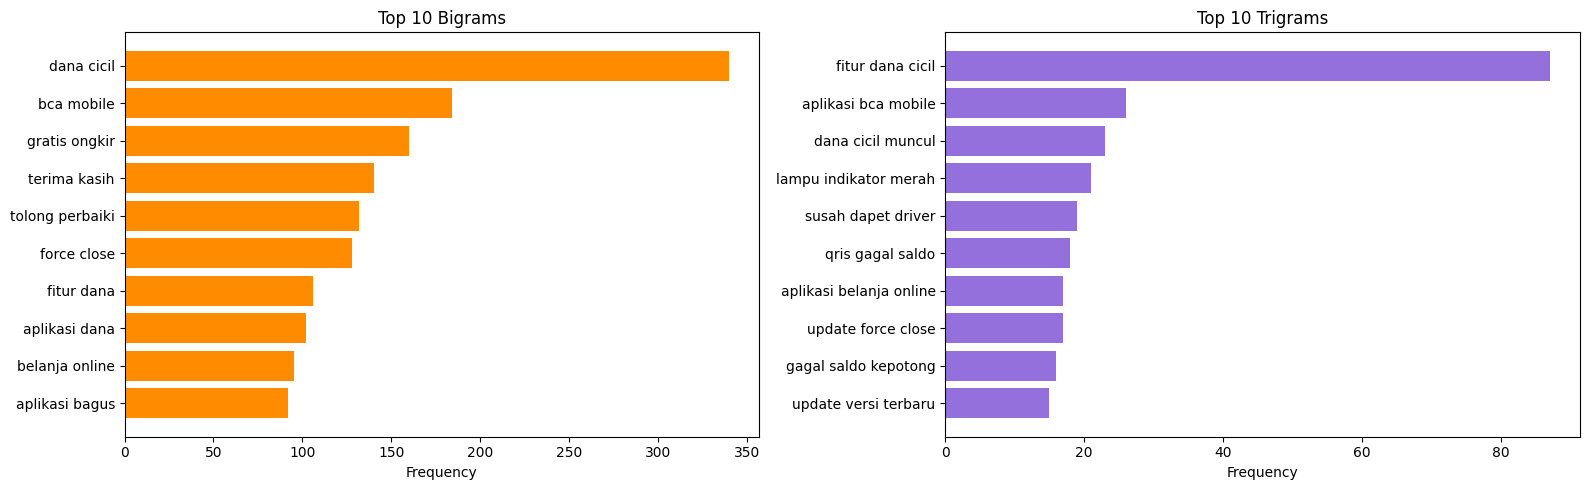

In [93]:
bigram_vec  = CountVectorizer(ngram_range=(2,2), max_features=3000, min_df=3)
trigram_vec = CountVectorizer(ngram_range=(3,3), max_features=2000, min_df=3)
X_bigram  = bigram_vec.fit_transform(df['text_clean'])
X_trigram = trigram_vec.fit_transform(df['text_clean'])

bg_freq   = np.asarray(X_bigram.sum(axis=0)).flatten()
tg_freq   = np.asarray(X_trigram.sum(axis=0)).flatten()
bg_vocab  = bigram_vec.get_feature_names_out()
tg_vocab  = trigram_vec.get_feature_names_out()
top_bg    = bg_freq.argsort()[::-1][:15]
top_tg    = tg_freq.argsort()[::-1][:15]

print('Top 15 Bigrams:')
for i, idx in enumerate(top_bg):
    print(f'  {i+1:2d}. "{bg_vocab[idx]}"  ({int(bg_freq[idx])})')

print('\nTop 15 Trigrams:')
for i, idx in enumerate(top_tg):
    print(f'  {i+1:2d}. "{tg_vocab[idx]}"  ({int(tg_freq[idx])})')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].barh([bg_vocab[i] for i in top_bg[:10]][::-1],
             [bg_freq[i]  for i in top_bg[:10]][::-1], color='darkorange')
axes[0].set_title('Top 10 Bigrams'); axes[0].set_xlabel('Frequency')
axes[1].barh([tg_vocab[i] for i in top_tg[:10]][::-1],
             [tg_freq[i]  for i in top_tg[:10]][::-1], color='mediumpurple')
axes[1].set_title('Top 10 Trigrams'); axes[1].set_xlabel('Frequency')
plt.tight_layout(); plt.show()

---
## Section 3: Word Embeddings

Represent words as **dense vectors** in a continuous space where semantically similar words are geometrically close.  
Unlike BoW/TF-IDF, embeddings capture **meaning and relationships**.

### 3.1 Word2Vec

Trains a shallow neural network to predict a word from its neighbours (CBOW) or  
predict neighbours from a word (Skip-gram).  
Result: each word is a vector where similar words cluster together in vector space.

Training Word2Vec...
Done. Vocabulary size: 3699

=== Word2Vec: Most Similar Words ===

  Most similar to "bagus":
    jaya                 0.8758
    overall              0.8748
    oke                  0.8736
    nyaman               0.8724
    slalu                0.8699

  Most similar to "lambat":
    spx                  0.9715
    pengirimannya        0.9630
    jne                  0.9629
    sampainya            0.9620
    express              0.9616

  Most similar to "error":
    restart              0.9776
    stabil               0.9771
    terputus             0.9731
    loading              0.9721
    eror                 0.9713

  Most similar to "driver":
    drivernya            0.9751
    gocar                0.9695
    cancel               0.9618
    gofood               0.9551
    orderan              0.9494

  Most similar to "aplikasi":
    app                  0.8995
    ringan               0.8935
    apk                  0.8934
    ih                   0.8893


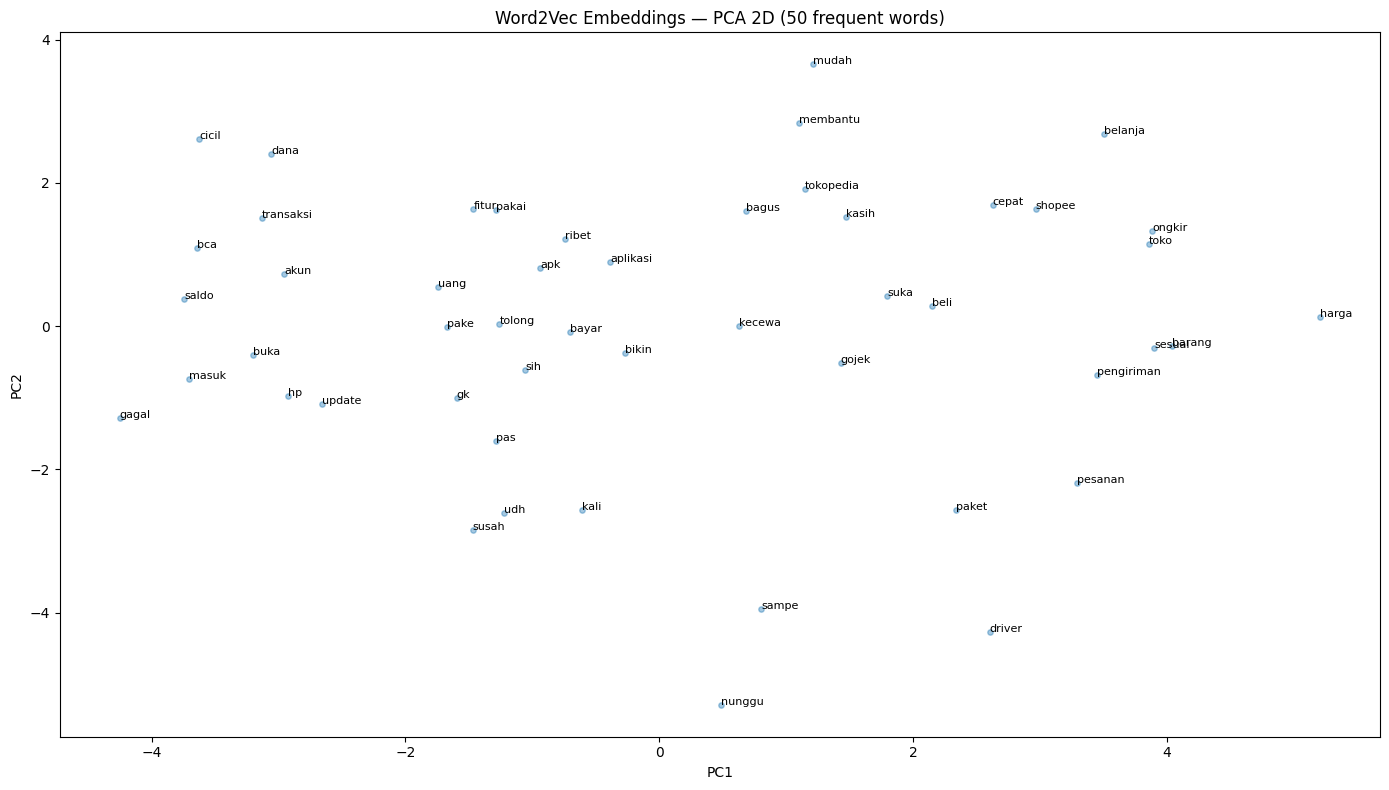

In [94]:
corpus_w2v = df['tokens'].tolist()

print('Training Word2Vec...')
w2v = Word2Vec(
    sentences=corpus_w2v,
    vector_size=100, window=5, min_count=3,
    workers=4, epochs=10, seed=42
)
print(f'Done. Vocabulary size: {len(w2v.wv)}\n')

print('=== Word2Vec: Most Similar Words ===\n')
test_words = ['bagus','lambat','error','driver','aplikasi']
for word in test_words:
    if word in w2v.wv:
        sim = w2v.wv.most_similar(word, topn=5)
        print(f'  Most similar to "{word}":')
        for w, s in sim:
            print(f'    {w:<20} {s:.4f}')
        print()

# Visualise top-50 frequent words with PCA
freq_words = [w for w in w2v.wv.key_to_index
              if w2v.wv.get_vecattr(w, 'count') > 30][:50]
vecs_2d = PCA(n_components=2, random_state=42).fit_transform(
    np.array([w2v.wv[w] for w in freq_words]))

fig, ax = plt.subplots(figsize=(14, 8))
ax.scatter(vecs_2d[:,0], vecs_2d[:,1], alpha=0.4, s=15)
for i, w in enumerate(freq_words):
    ax.annotate(w, (vecs_2d[i,0], vecs_2d[i,1]), fontsize=8)
ax.set_title('Word2Vec Embeddings — PCA 2D (50 frequent words)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.tight_layout(); plt.show()

### 3.2 GloVe (Global Vectors for Word Representation)

GloVe captures **global co-occurrence statistics** across the entire corpus.  
Objective: minimise a weighted least-squares loss over the co-occurrence matrix.

We implement and train GloVe from scratch below.

In [95]:
class SimpleGloVe:
    """Minimal GloVe implementation trained with AdaGrad."""

    def __init__(self, vector_size=50, window=3, epochs=10, lr=0.05,
                 x_max=100, alpha=0.75, vocab_size=500):
        self.D, self.win, self.epochs = vector_size, window, epochs
        self.lr, self.x_max, self.alpha = lr, x_max, alpha
        self.vocab_size = vocab_size

    def _build(self, sentences):
        freq = Counter(w for s in sentences for w in s)
        vocab = [w for w, _ in freq.most_common(self.vocab_size)]
        self.w2i = {w: i for i, w in enumerate(vocab)}
        self.i2w = vocab
        self.V   = len(vocab)
        cooc = defaultdict(float)
        for sent in sentences:
            ids = [self.w2i[w] for w in sent if w in self.w2i]
            for ci, c in enumerate(ids):
                for xi in range(max(0, ci-self.win),
                                min(len(ids), ci+self.win+1)):
                    if ci != xi:
                        cooc[(c, ids[xi])] += 1.0 / abs(ci - xi)
        return cooc

    def fit(self, sentences):
        cooc = self._build(sentences)
        V, D = self.V, self.D
        rng  = np.random.RandomState(42)
        self.W  = rng.normal(0, .01, (V, D))
        self.Wc = rng.normal(0, .01, (V, D))
        self.b   = np.zeros(V); self.bc  = np.zeros(V)
        gW  = np.ones((V,D)); gWc = np.ones((V,D))
        gb  = np.ones(V);     gbc = np.ones(V)
        pairs = list(cooc.items())
        print(f'  Vocab={V}, pairs={len(pairs)}, epochs={self.epochs}')
        for ep in range(self.epochs):
            loss = 0.0
            np.random.shuffle(pairs)
            for (i,j), xij in pairs:
                wf  = (xij/self.x_max)**self.alpha if xij < self.x_max else 1.
                inn = self.W[i]@self.Wc[j] + self.b[i] + self.bc[j] - np.log(xij+1e-8)
                loss += .5*wf*inn**2
                g   = wf*inn
                gWi = g*self.Wc[j]; gWcj = g*self.W[i]
                self.W[i]  -= self.lr*gWi  / np.sqrt(gW[i])
                self.Wc[j] -= self.lr*gWcj / np.sqrt(gWc[j])
                self.b[i]  -= self.lr*g    / np.sqrt(gb[i])
                self.bc[j] -= self.lr*g    / np.sqrt(gbc[j])
                gW[i]+=gWi**2; gWc[j]+=gWcj**2; gb[i]+=g**2; gbc[j]+=g**2
            if (ep+1)%2==0:
                print(f'  Epoch {ep+1:2d}/{self.epochs}  loss={loss:.1f}')
        self.vectors = self.W + self.Wc
        return self

    def most_similar(self, word, topn=5):
        if word not in self.w2i: return []
        q = self.vectors[self.w2i[word]]
        norms = np.linalg.norm(self.vectors, axis=1) + 1e-8
        sims  = (self.vectors @ q) / (norms * (np.linalg.norm(q)+1e-8))
        top   = np.argsort(sims)[::-1][1:topn+1]
        return [(self.i2w[i], float(sims[i])) for i in top]

print('Training GloVe (from scratch)...')
glove = SimpleGloVe(vector_size=50, window=3, epochs=10, vocab_size=500)
glove.fit(corpus_w2v[:3000])
print('Done!\n')

print('=== GloVe: Most Similar Words ===\n')
for word in ['bagus','error','driver','aplikasi']:
    sim = glove.most_similar(word, topn=5)
    if sim:
        print(f'  Most similar to "{word}":')
        for w, s in sim:
            print(f'    {w:<20} {s:.4f}')
        print()
    else:
        print(f'  "{word}" not in GloVe vocabulary\n')

Training GloVe (from scratch)...
  Vocab=500, pairs=47950, epochs=10
  Epoch  2/10  loss=704.0
  Epoch  4/10  loss=624.6
  Epoch  6/10  loss=596.0
  Epoch  8/10  loss=581.1
  Epoch 10/10  loss=571.3
Done!

=== GloVe: Most Similar Words ===

  Most similar to "bagus":
    aplikasi             0.7993
    buka                 0.6764
    membantu             0.6075
    update               0.5871
    pake                 0.5494

  Most similar to "error":
    pelayanan            0.4594
    notif                0.4096
    internet             0.3310
    sistemnya            0.3182
    sma                  0.3084

  Most similar to "driver":
    dpt                  0.6249
    cancel               0.5987
    gojek                0.5596
    nunggu               0.5487
    cari                 0.5330

  Most similar to "aplikasi":
    dana                 0.8451
    buka                 0.8132
    bagus                0.7993
    cicil                0.7979
    membantu             0.7653



### 3.3 FastText

Extends Word2Vec by representing each word as the **sum of its subword character n-grams**.  

Example: `"aplikasi"` → `["apli", "plik", "lika", "ikas", "kasi", ...]`

**Key advantage:** can produce vectors for OOV (out-of-vocabulary) words,  
including misspellings and rare morphological forms.

In [96]:
print('Training FastText...')
ft = FastText(
    sentences=corpus_w2v,
    vector_size=100, window=5, min_count=3,
    min_n=3, max_n=6, workers=4, epochs=10, seed=42
)
print(f'Done. Vocabulary size: {len(ft.wv)}\n')

print('=== FastText: Most Similar Words ===\n')
for word in ['bagus','error','driver','aplikasi','pelayanan']:
    try:
        sim = ft.wv.most_similar(word, topn=5)
        print(f'  Most similar to "{word}":')
        for w, s in sim:
            print(f'    {w:<20} {s:.4f}')
        print()
    except Exception as e:
        print(f'  Error for "{word}": {e}\n')

# Strength: handles OOV / misspelled words
print('=== FastText vs Word2Vec on OOV words ===\n')
oov_words = ['aplicasi','erorr','baguus','drver','pelyanan']
for word in oov_words:
    try:
        sim  = ft.wv.most_similar(word, topn=3)
        hits = ', '.join(f"{w}({s:.2f})" for w, s in sim)
        print(f'  FastText  "{word}" -> {hits}')
    except Exception as e:
        print(f'  FastText  "{word}" -> error: {e}')
    try:
        _ = w2v.wv[word]
        print(f'  Word2Vec  "{word}" -> found in vocab')
    except KeyError:
        print(f'  Word2Vec  "{word}" -> KeyError (not in vocab)')
    print()

Training FastText...
Done. Vocabulary size: 3699

=== FastText: Most Similar Words ===

  Most similar to "bagus":
    bagus2               0.9882
    baguss               0.9832
    sebagus              0.9760
    bagusss              0.9706
    apl                  0.9225

  Most similar to "error":
    erorr                0.9957
    eror                 0.9954
    eror2                0.9924
    simcard              0.9823
    cba                  0.9822

  Most similar to "driver":
    drive                0.9982
    driver2              0.9978
    driverny             0.9973
    drivernya            0.9891
    gocar                0.9887

  Most similar to "aplikasi":
    applikasi            0.9598
    aplikasiny           0.9460
    aplikasinya          0.9315
    apl                  0.9210
    bersih               0.9178

  Most similar to "pelayanan":
    pelayan              0.9922
    layanan              0.9865
    pelayananya          0.9789
    pelayanannya         0.97

---
## Section 4: Classical ML Models

Use TF-IDF features for binary sentiment classification:  
**0 = Negative/Neutral, 1 = Positive**

Models: KNN, Decision Tree, Random Forest, Naive Bayes, SVM

In [97]:
X = X_tfidf
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Features shape  : {X.shape}')
print(f'Train samples   : {X_train.shape[0]}')
print(f'Test  samples   : {X_test.shape[0]}')
print(f'Train label dist: {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'Test  label dist: {dict(zip(*np.unique(y_test,  return_counts=True)))}')

results_ml = {}

Features shape  : (10000, 5000)
Train samples   : 8000
Test  samples   : 2000
Train label dist: {np.int64(0): np.int64(7161), np.int64(1): np.int64(839)}
Test  label dist: {np.int64(0): np.int64(1790), np.int64(1): np.int64(210)}


### 4.1 K-Nearest Neighbors (KNN)

In [98]:
print('Training KNN...')
knn = KNeighborsClassifier(n_neighbors=5, metric='cosine', n_jobs=-1)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
acc = accuracy_score(y_test, y_pred)
results_ml['KNN'] = acc
print(f'KNN Test Accuracy: {acc:.4f} ({acc*100:.2f}%)\n')
print(classification_report(y_test, y_pred, target_names=['Negative','Positive']))

Training KNN...
KNN Test Accuracy: 0.8840 (88.40%)

              precision    recall  f1-score   support

    Negative       0.90      0.98      0.94      1790
    Positive       0.27      0.06      0.10       210

    accuracy                           0.88      2000
   macro avg       0.58      0.52      0.52      2000
weighted avg       0.83      0.88      0.85      2000



### 4.2 Decision Tree

In [99]:
print('Training Decision Tree...')
dt = DecisionTreeClassifier(max_depth=20, random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
acc = accuracy_score(y_test, y_pred)
results_ml['Decision Tree'] = acc
print(f'Decision Tree Test Accuracy: {acc:.4f} ({acc*100:.2f}%)\n')
print(classification_report(y_test, y_pred, target_names=['Negative','Positive']))

Training Decision Tree...
Decision Tree Test Accuracy: 0.8810 (88.10%)

              precision    recall  f1-score   support

    Negative       0.90      0.97      0.94      1790
    Positive       0.28      0.09      0.13       210

    accuracy                           0.88      2000
   macro avg       0.59      0.53      0.53      2000
weighted avg       0.84      0.88      0.85      2000



### 4.3 Random Forest

In [100]:
print('Training Random Forest (may take a moment)...')
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
results_ml['Random Forest'] = acc
print(f'Random Forest Test Accuracy: {acc:.4f} ({acc*100:.2f}%)\n')
print(classification_report(y_test, y_pred, target_names=['Negative','Positive']))

Training Random Forest (may take a moment)...
Random Forest Test Accuracy: 0.8925 (89.25%)

              precision    recall  f1-score   support

    Negative       0.90      0.99      0.94      1790
    Positive       0.35      0.03      0.05       210

    accuracy                           0.89      2000
   macro avg       0.63      0.51      0.50      2000
weighted avg       0.84      0.89      0.85      2000



### 4.4 Naive Bayes (Multinomial)

In [101]:
print('Training Naive Bayes...')
nb = MultinomialNB(alpha=0.1)
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)
acc = accuracy_score(y_test, y_pred)
results_ml['Naive Bayes'] = acc
print(f'Naive Bayes Test Accuracy: {acc:.4f} ({acc*100:.2f}%)\n')
print(classification_report(y_test, y_pred, target_names=['Negative','Positive']))

Training Naive Bayes...
Naive Bayes Test Accuracy: 0.8880 (88.80%)

              precision    recall  f1-score   support

    Negative       0.90      0.99      0.94      1790
    Positive       0.23      0.03      0.05       210

    accuracy                           0.89      2000
   macro avg       0.56      0.51      0.50      2000
weighted avg       0.83      0.89      0.85      2000



### 4.5 Support Vector Machine (SVM)

In [102]:
print('Training SVM (LinearSVC)...')
svm = LinearSVC(C=1.0, random_state=42, max_iter=2000)
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)
acc = accuracy_score(y_test, y_pred)
results_ml['SVM'] = acc
print(f'SVM Test Accuracy: {acc:.4f} ({acc*100:.2f}%)\n')
print(classification_report(y_test, y_pred, target_names=['Negative','Positive']))

Training SVM (LinearSVC)...
SVM Test Accuracy: 0.8870 (88.70%)

              precision    recall  f1-score   support

    Negative       0.90      0.98      0.94      1790
    Positive       0.36      0.10      0.16       210

    accuracy                           0.89      2000
   macro avg       0.63      0.54      0.55      2000
weighted avg       0.85      0.89      0.86      2000



### Classical ML — Comparison

=== Classical ML Comparison ===

  Model             Accuracy
  ----------------------------
  Random Forest   0.8925  ######################
  Naive Bayes     0.8880  ######################
  SVM             0.8870  ######################
  KNN             0.8840  ######################
  Decision Tree   0.8810  ######################


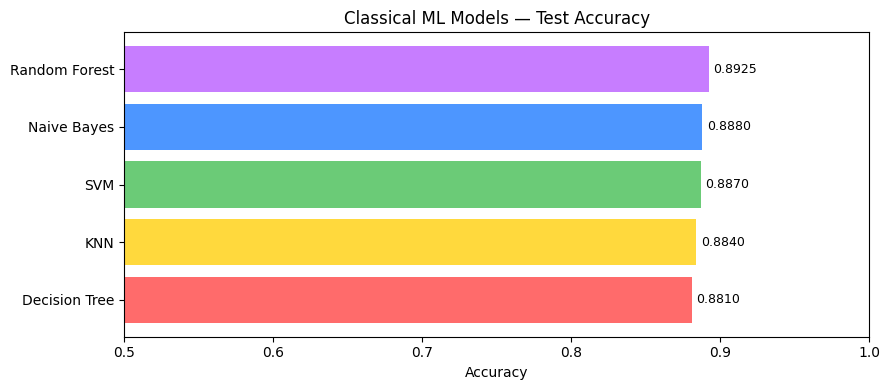

In [103]:
print('=== Classical ML Comparison ===\n')
print(f'  {"Model":<15} {"Accuracy":>10}')
print('  ' + '-'*28)
for name, acc in sorted(results_ml.items(), key=lambda x: -x[1]):
    bar = '#' * int(acc * 25)
    print(f'  {name:<15} {acc:.4f}  {bar}')

fig, ax = plt.subplots(figsize=(9, 4))
sorted_ml = sorted(results_ml.items(), key=lambda x: x[1])
ax.barh([m[0] for m in sorted_ml], [m[1] for m in sorted_ml],
        color=['#ff6b6b','#ffd93d','#6bcb77','#4d96ff','#c77dff'])
ax.set_xlim(0.5, 1.0)
ax.set_xlabel('Accuracy')
ax.set_title('Classical ML Models — Test Accuracy')
for bar, (_, acc) in zip(ax.patches, sorted_ml):
    ax.text(bar.get_width()+.003, bar.get_y()+bar.get_height()/2,
            f'{acc:.4f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

---
## Section 5: Neural Network Models

Process text as an **ordered sequence** — word position matters.

```
Input tokens → Embedding → Recurrent Layer → Dense → Sigmoid
```

| Model | Gate structure | Strength |
|-------|---------------|----------|
| RNN   | None (basic)  | Fast, simple; struggles with long sequences |
| LSTM  | Forget / Input / Output | Long-range dependencies |
| GRU   | Reset / Update | Fewer parameters than LSTM, similar accuracy |

### Data Preparation for Sequence Models

In [104]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print(f'TensorFlow: {tf.__version__}')

MAX_VOCAB  = 10000
MAX_LEN    = 100
EMBED_DIM  = 64
BATCH_SIZE = 256
EPOCHS     = 5

tok = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tok.fit_on_texts(df['text_clean'])
seqs   = tok.texts_to_sequences(df['text_clean'])
X_seq  = pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')
y_nn   = df['label'].values

print(f'Vocab size  : {len(tok.word_index)}')
print(f'Sequences   : {X_seq.shape}')

X_tr, X_te, y_tr, y_te = train_test_split(
    X_seq, y_nn, test_size=0.2, random_state=42, stratify=y_nn)
print(f'Train: {X_tr.shape}   Test: {X_te.shape}')

es = EarlyStopping(monitor='val_loss', patience=2,
                   restore_best_weights=True, verbose=0)
results_nn  = {}
histories   = {}

# Class weights to handle class imbalance
from sklearn.utils.class_weight import compute_class_weight
# Soft class weight: cap minority boost at 3x to keep training stable
n0, n1 = np.bincount(y_tr)
w1 = min(n0 / n1, 3.0)   # cap at 3x
class_weight = {0: 1.0, 1: w1}
print(f'Class weights: {class_weight}  (ratio: {w1:.2f}x)')

TensorFlow: 2.21.0
Vocab size  : 12020
Sequences   : (10000, 100)
Train: (8000, 100)   Test: (2000, 100)
Class weights: {0: 1.0, 1: 3.0}  (ratio: 3.00x)


### 5.1 Simple RNN

In [105]:
rnn_model = Sequential([
    Embedding(MAX_VOCAB, EMBED_DIM, input_length=MAX_LEN),
    SimpleRNN(64, dropout=0.2),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1,  activation='sigmoid'),
], name='SimpleRNN')

rnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0),
    loss='binary_crossentropy', metrics=['accuracy'])
rnn_model.build(input_shape=(None, MAX_LEN))
rnn_model.summary()

print('\nTraining Simple RNN...')
h = rnn_model.fit(X_tr, y_tr, validation_data=(X_te, y_te),
                  epochs=EPOCHS, batch_size=BATCH_SIZE,
                  class_weight=class_weight, callbacks=[es], verbose=1)
histories['RNN'] = h

_, acc = rnn_model.evaluate(X_te, y_te, verbose=0)
results_nn['RNN'] = acc
print(f'\nSimple RNN Test Accuracy: {acc:.4f}')

Model: "SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ (None, 100, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 650,369 (2.48 MB)

 Trainable params: 650,369 (2.48 MB)

 Non-trainable params: 0 (0.00 B)


Training Simple RNN...
Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.8932 - loss: 0.7148 - val_accuracy: 0.8950 - val_loss: 0.4240
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8951 - loss: 0.6991 - val_accuracy: 0.8950 - val_loss: 0.4107
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8814 - loss: 0.6938 - val_accuracy: 0.8950 - val_loss: 0.4154
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8932 - loss: 0.7210 - val_accuracy: 0.8950 - val_loss: 0.4172

Simple RNN Test Accuracy: 0.8950


### 5.2 LSTM

In [106]:
lstm_model = Sequential([
    Embedding(MAX_VOCAB, EMBED_DIM, input_length=MAX_LEN),
    LSTM(64, dropout=0.2),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1,  activation='sigmoid'),
], name='LSTM')

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0),
    loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.build(input_shape=(None, MAX_LEN))
lstm_model.summary()

print('\nTraining LSTM...')
h = lstm_model.fit(X_tr, y_tr, validation_data=(X_te, y_te),
                   epochs=EPOCHS, batch_size=BATCH_SIZE,
                   class_weight=class_weight, callbacks=[es], verbose=1)
histories['LSTM'] = h

_, acc = lstm_model.evaluate(X_te, y_te, verbose=0)
results_nn['LSTM'] = acc
print(f'\nLSTM Test Accuracy: {acc:.4f}')

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ (None, 100, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,137 (2.58 MB)

 Trainable params: 675,137 (2.58 MB)

 Non-trainable params: 0 (0.00 B)


Training LSTM...
Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.8788 - loss: 0.7296 - val_accuracy: 0.8950 - val_loss: 0.4255
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.8951 - loss: 0.6995 - val_accuracy: 0.8950 - val_loss: 0.4268

LSTM Test Accuracy: 0.8950


### 5.3 GRU

In [107]:
gru_model = Sequential([
    Embedding(MAX_VOCAB, EMBED_DIM, input_length=MAX_LEN),
    GRU(64, dropout=0.2),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1,  activation='sigmoid'),
], name='GRU')

gru_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0),
    loss='binary_crossentropy', metrics=['accuracy'])
gru_model.build(input_shape=(None, MAX_LEN))
gru_model.summary()

print('\nTraining GRU...')
h = gru_model.fit(X_tr, y_tr, validation_data=(X_te, y_te),
                  epochs=EPOCHS, batch_size=BATCH_SIZE,
                  class_weight=class_weight, callbacks=[es], verbose=1)
histories['GRU'] = h

_, acc = gru_model.evaluate(X_te, y_te, verbose=0)
results_nn['GRU'] = acc
print(f'\nGRU Test Accuracy: {acc:.4f}')

Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ (None, 100, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 667,073 (2.54 MB)

 Trainable params: 667,073 (2.54 MB)

 Non-trainable params: 0 (0.00 B)


Training GRU...
Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.8913 - loss: 0.7170 - val_accuracy: 0.8950 - val_loss: 0.4259
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.8951 - loss: 0.7029 - val_accuracy: 0.8950 - val_loss: 0.4207

GRU Test Accuracy: 0.8950


### Neural Network Training Curves & Full Model Comparison

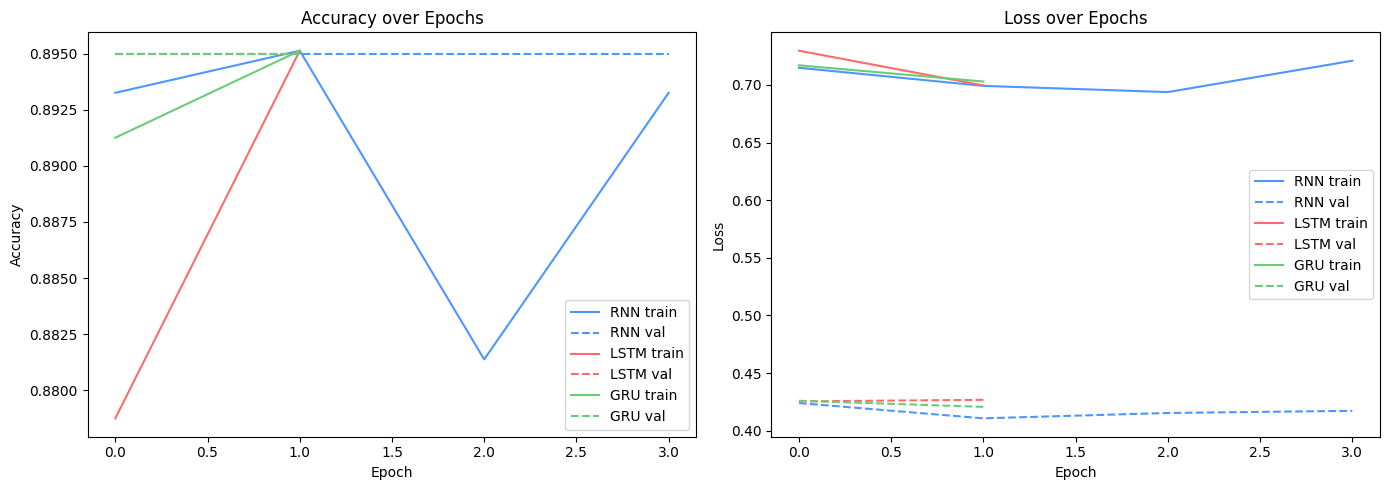


=== Full Model Comparison ===

  Model           Type            Accuracy
  ------------------------------------------
  RNN             Neural Net    0.8950
  LSTM            Neural Net    0.8950
  GRU             Neural Net    0.8950
  Random Forest   Classical ML  0.8925
  Naive Bayes     Classical ML  0.8880
  SVM             Classical ML  0.8870
  KNN             Classical ML  0.8840
  Decision Tree   Classical ML  0.8810


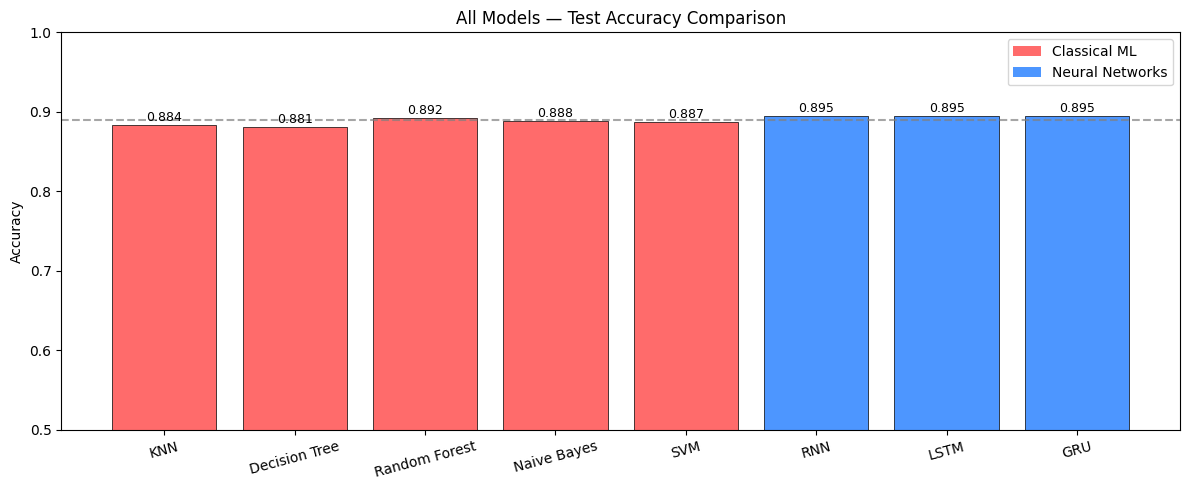

In [108]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'RNN':'#4d96ff', 'LSTM':'#ff6b6b', 'GRU':'#6bcb77'}
for name, h in histories.items():
    c = colors[name]
    axes[0].plot(h.history['accuracy'],     color=c,  label=f'{name} train')
    axes[0].plot(h.history['val_accuracy'], color=c,  label=f'{name} val', linestyle='--')
    axes[1].plot(h.history['loss'],         color=c,  label=f'{name} train')
    axes[1].plot(h.history['val_loss'],     color=c,  label=f'{name} val', linestyle='--')
for ax, title, ylabel in [
    (axes[0], 'Accuracy over Epochs', 'Accuracy'),
    (axes[1], 'Loss over Epochs',     'Loss')
]:
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel); ax.legend()
plt.tight_layout(); plt.show()

# Full comparison
all_results = {**results_ml, **results_nn}
print('\n=== Full Model Comparison ===\n')
print(f'  {"Model":<15} {"Type":<13} {"Accuracy":>10}')
print('  ' + '-'*42)
for name, acc in sorted(all_results.items(), key=lambda x: -x[1]):
    mtype = 'Neural Net' if name in results_nn else 'Classical ML'
    print(f'  {name:<15} {mtype:<13} {acc:.4f}')

fig, ax = plt.subplots(figsize=(12, 5))
names_all = list(all_results.keys())
accs_all  = [all_results[n] for n in names_all]
bar_colors = ['#4d96ff' if n in results_nn else '#ff6b6b' for n in names_all]
bars = ax.bar(names_all, accs_all, color=bar_colors, edgecolor='black', linewidth=0.5)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Accuracy')
ax.set_title('All Models — Test Accuracy Comparison')
ax.axhline(np.mean(accs_all), color='gray', linestyle='--', alpha=0.7)
for bar, acc in zip(bars, accs_all):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{acc:.3f}', ha='center', fontsize=9)
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#ff6b6b', label='Classical ML'),
    Patch(facecolor='#4d96ff', label='Neural Networks'),
])
plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

---
## Summary

### Text Preprocessing
| Step | Purpose |
|------|---------|
| Text Cleaning | Remove noise (emoji, URLs, HTML, special chars) |
| Casefolding | Normalise capitalisation |
| Tokenisasi | Split into word tokens |
| POS Tagging | Label grammatical roles |
| Stopword Removal | Remove low-information words |

### Feature Extraction
| Method | Strength | Weakness |
|--------|----------|----------|
| Bag of Words | Simple, interpretable | Sparse, ignores word order |
| TF-IDF | Weights informative words | Still no semantic meaning |
| N-gram | Captures phrases | Vocabulary grows exponentially |

### Word Embeddings
| Method | Key Idea | Best for |
|--------|----------|----------|
| Word2Vec | Local context prediction | General embeddings |
| GloVe | Global co-occurrence | Semantic analogies |
| FastText | Subword n-grams | Morphology-rich languages, OOV |

### Model Selection
- **SVM + TF-IDF**: Strong, fast baseline for text classification
- **LSTM / GRU**: Better when word order and long context matter
- **GRU**: Comparable accuracy to LSTM with fewer parameters
